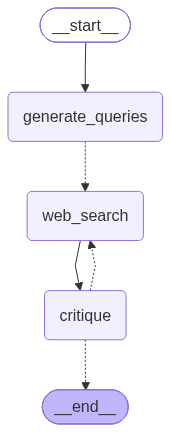

<loguru.logger handlers=[(id=1, level=20, sink=stderr), (id=2, level=10, sink='logs/ZhiPoAI_DR_{time:YYYY-MM-DD}.log')]>

In [2]:

import asyncio
import json
import sys
import pathlib



from dotenv import load_dotenv
load_dotenv()  # 读取 backend/.env

from loguru import logger
from agent.task_queue import (
    enqueue_task,
    start_worker,
    read_task_events,
    TASK_STREAM,
)
from agent.logger import setup_logger

setup_logger()


In [6]:
print("\n" + "=" * 70)
print("  [Step 1] 模拟 POST /api/research")
print("=" * 70)

# ── 入参（对应 app.py:138 解析后的 body）────────────────────
body = {
    "messages": [
        {"type": "human", "content": "深度调研欧美发达国家酒店旅游业，在AI Agent 的发展应用和落地方案"},
    ],
    "initial_search_query_count": 2,
    "max_research_loops": 2,
    "reasoning_model": "MiniMax-M3",
    "plan_status": "unconfirmed",   # 首次进入：触发 generate_plan
    "plan": "",
}

async def task()->str:
    task_id = await enqueue_task(
        messages=body["messages"],
        initial_search_query_count=body["initial_search_query_count"],
        max_research_loops=body["max_research_loops"],
        reasoning_model=body["reasoning_model"],
        plan_status=body["plan_status"],
        plan=body["plan"],
        # task_id 不传 → 自动生成 UUID；想断点续传则固定传一个值
    )
    print(f"  → task_id 已下发: {task_id}")
    return task_id

task_id = await task()
print(task_id)


2026-09-13 14:35:45 | INFO     | agent.task_queue:enqueue_task:108 - [TaskQueue] 任务已入队 task_id=34dfae26...



  [Step 1] 模拟 POST /api/research
  → task_id 已下发: 34dfae26-3cff-4329-9e5b-6269094d57b4
34dfae26-3cff-4329-9e5b-6269094d57b4
